### Data Distribution

In [ ]:
for col in merged.select_dtypes('number').columns:
    if col in ['id', 'study_interval', 'day_in_study']:
        continue
    print(f"{col}: {(merged[col]==0).mean()*100:.0f}% zeros, skew={merged[col].skew():.1f}")

mean_temp: 0% zeros, skew=-0.4
max_temp: 0% zeros, skew=0.2
min_temp: 0% zeros, skew=0.8
std_temp: 9% zeros, skew=-0.6
mean_rmssd: 0% zeros, skew=1.3
max_rmssd: 0% zeros, skew=1.6
min_rmssd: 0% zeros, skew=1.8
std_rmssd: 15% zeros, skew=1.5
mean_high_frequency: 0% zeros, skew=2.4
max_high_frequency: 0% zeros, skew=2.4
min_high_frequency: 0% zeros, skew=6.5
std_high_frequency: 15% zeros, skew=2.3
mean_vo2: 0% zeros, skew=0.6
max_vo2: 0% zeros, skew=1.7
min_vo2: 0% zeros, skew=0.5
std_vo2: 81% zeros, skew=3.5
mean_bpm: 0% zeros, skew=-0.6
max_bpm: 0% zeros, skew=-0.4
min_bpm: 0% zeros, skew=0.4
std_bpm: 66% zeros, skew=1.1


Since, I'm planning on using linear models, I will log-transform some features.

I will skip the std columns for now because they are very heavily 0-inflated due to what I did above.

For the rest of the columns, if their skew is < 1 I will leave them as is because they are symmetrical. If their skew is > 1, I will log transform

In [ ]:
import numpy as np

log_cols = [
    'mean_rmssd', 'max_rmssd', 'min_rmssd',
    'mean_high_frequency', 'max_high_frequency', 'min_high_frequency',
    'max_vo2',
]

for col in log_cols:
    merged[col] = np.log1p(merged[col])

for col in log_cols:
    print(f"{col}: skew now {merged[col].skew():.1f}")

mean_rmssd: skew now -0.1
max_rmssd: skew now 0.0
min_rmssd: skew now 0.1
mean_high_frequency: skew now -0.2
max_high_frequency: skew now -0.1
min_high_frequency: skew now -0.1
max_vo2: skew now 0.3


In [ ]:
# see if any 'left alone' column has extreme outliers worth capping
for col in ['max_temp', 'min_temp', 'mean_rmssd', 'min_rmssd', 'max_rmssd', 'mean_high_frequency', 'min_high_frequency', 'max_high_frequency',
                 'mean_bpm', 'min_bpm', 'max_bpm', 'mean_vo2', 'min_vo2', 'max_vo2']:
    q1, q3 = merged[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper, lower = q3 + 3*iqr, q1 - 3*iqr
    n_out = ((merged[col] > upper) | (merged[col] < lower)).sum()
    print(f"{col}: {n_out} extreme outliers beyond 3×IQR")

max_temp: 39 extreme outliers beyond 3×IQR
min_temp: 0 extreme outliers beyond 3×IQR
mean_rmssd: 0 extreme outliers beyond 3×IQR
min_rmssd: 0 extreme outliers beyond 3×IQR
max_rmssd: 0 extreme outliers beyond 3×IQR
mean_high_frequency: 0 extreme outliers beyond 3×IQR
min_high_frequency: 1 extreme outliers beyond 3×IQR
max_high_frequency: 0 extreme outliers beyond 3×IQR
mean_bpm: 10 extreme outliers beyond 3×IQR
min_bpm: 0 extreme outliers beyond 3×IQR
max_bpm: 0 extreme outliers beyond 3×IQR
mean_vo2: 10 extreme outliers beyond 3×IQR
min_vo2: 2 extreme outliers beyond 3×IQR
max_vo2: 45 extreme outliers beyond 3×IQR


But looking at the outlier values below, are they actually extreme? No, so I don't want to capp and risk losing valuable information about the relationship between these features and stress.

In [ ]:
def show_outlier_values(col):
    q1, q3 = merged[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper, lower = q3 + 3*iqr, q1 - 3*iqr
    outliers = merged[(merged[col] > upper) | (merged[col] < lower)][col]
    print(f"{col}: normal range {lower:.1f} to {upper:.1f}")
    print(f"  extreme values: {sorted(outliers.round(1).tolist())}")

for col in ['max_temp', 'mean_bpm', 'mean_vo2', 'max_vo2']:
    show_outlier_values(col)

max_temp: normal range -1.0 to 4.9
  extreme values: [-7.9, -6.5, -5.8, -4.4, -1.2, 4.9, 4.9, 4.9, 5.0, 5.0, 5.0, 5.1, 5.1, 5.1, 5.1, 5.2, 5.2, 5.3, 5.3, 5.3, 5.4, 5.4, 5.4, 5.5, 5.5, 5.6, 5.6, 5.6, 5.6, 5.7, 5.7, 5.7, 5.7, 5.8, 6.1, 6.2, 6.3, 6.4, 6.5]
mean_bpm: normal range 50.1 to 89.7
  extreme values: [47.6, 48.5, 48.8, 49.3, 49.6, 49.7, 49.9, 49.9, 49.9, 49.9]
mean_vo2: normal range 7.1 to 66.3
  extreme values: [68.7, 68.7, 72.7, 72.7, 77.1, 77.1, 82.0, 82.0, 87.5, 87.5]
max_vo2: normal range 3.0 to 4.3
  extreme values: [4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5]


I wanted to check if any feature needed smoothing and before checking through code, temperature would be the one to check because it shouldn't be varying a lot through for a participant during a study interval. The rest can fluctuate more (except vo2 which doens't vary a lot anyway)

In [ ]:
key_sort = ['id', 'study_interval', 'day_in_study']
merged = merged.sort_values(key_sort)

for col in ['mean_temp', 'mean_bpm', 'mean_rmssd', 'mean_vo2']:

    daily_change = (merged.groupby(['id','study_interval'])[col]
                    .diff().abs().mean())
    overall_std = merged[col].std()
    ratio = daily_change / overall_std
    print(f"{col}: avg daily change = {daily_change:.2f}, "
          f"std = {overall_std:.2f}, ratio = {ratio:.2f}")

mean_temp: avg daily change = 0.58, std = 0.92, ratio = 0.63
mean_bpm: avg daily change = 0.88, std = 5.91, ratio = 0.15
mean_rmssd: avg daily change = 0.17, std = 0.47, ratio = 0.37
mean_vo2: avg daily change = 0.29, std = 6.54, ratio = 0.04


As expected temperature is the one with a high ratio and may need smoothing. I looked at how big is a typical daily jump compared to the temperature signal's whole range.

Wrist temperature should move slowly not jump. Even across menstural cycle phases, it fluctuates, but that's a multi-day fluctuation not spikes day-to-day. But I want to do another check to ensure that these fluctuations are actually noise and not signals I could be ignoring.

In [ ]:
key_sort = ['id', 'study_interval', 'day_in_study']
merged = merged.sort_values(key_sort)

# looks at how big are day-to-day temp jumps, relative to the signal's range
daily_change = merged.groupby(['id','study_interval'])['mean_temp'].diff().abs()
print("Median daily change:", daily_change.median())
print("Overall temp std:   ", merged['mean_temp'].std())
print("Ratio:", daily_change.median() / merged['mean_temp'].std())

Median daily change: 0.4284796795622794
Overall temp std:    0.9169123016314038
Ratio: 0.4673071555479327


The median day-to-day change relative to the overall spread was 0.47, indicating moderate noise. The mean-based ratio was higher (0.63), and the gap between the two shows that while most daily changes are modest, a few are large. According to Simic et al. (2025) [link text](https://pmc.ncbi.nlm.nih.gov/articles/PMC12608656/#B9-sensors-25-06592), wrist temperature during a stress event may lead to a drop of 1 to 3 degrees C. Therefore, these big jumps could potentially be due to stress and I shouldn't smooth.

### Target Distribution

Merging the target stress column to merged and dropping rows in merged where stress is NaN

In [ ]:
hormones = pd.read_csv('/content/drive/MyDrive/ML csv files/hormones_and_selfreport.csv')
print([c for c in hormones.columns if 'stress' in c.lower()])
print(hormones.columns.tolist())

['stress']
['id', 'study_interval', 'is_weekend', 'day_in_study', 'phase', 'lh', 'estrogen', 'pdg', 'flow_volume', 'flow_color', 'appetite', 'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']


In [ ]:
stress_df = hormones[key + ['stress']]
merged = merged.merge(stress_df, on=key, how='left', validate='one_to_one')


print("Total rows:", len(merged))
print("Rows missing stress:", merged['stress'].isna().sum())
print("\nStress distribution:")
print(merged['stress'].value_counts(dropna=False))

Total rows: 5658
Rows missing stress: 2332

Stress distribution:
stress
NaN                2332
Moderate           1047
High                610
Low                 567
Not at all          436
Very Low/Little     369
Very High           290
2                     4
3                     2
1                     1
Name: count, dtype: int64


In [ ]:
merged = merged.dropna(subset=['stress'])
print("Rows after dropping unlabeled:", len(merged))

Rows after dropping unlabeled: 3326


In [ ]:
print(merged['stress'].value_counts())
print(merged['stress'].value_counts(normalize=True))

stress
Moderate           1047
High                610
Low                 567
Not at all          436
Very Low/Little     369
Very High           290
2                     4
3                     2
1                     1
Name: count, dtype: int64
stress
Moderate           0.314793
High               0.183403
Low                0.170475
Not at all         0.131088
Very Low/Little    0.110944
Very High          0.087192
2                  0.001203
3                  0.000601
1                  0.000301
Name: proportion, dtype: float64


I'm going to remove the 2,3,1 classes because it's likely junk and irrelevant as I don't know what they mean

In [ ]:
valid_labels = ['Moderate', 'High', 'Low', 'Not at all', 'Very Low/Little', 'Very High']
before = len(merged)
merged = merged[merged['stress'].isin(valid_labels)]

I will group the 6 classes into three instead (Low / Moderate / High) so it's easier to model, otherwise I have too few examples to learn

In [ ]:
stress_map = {
    'Not at all': 'Low', 'Very Low/Little': 'Low', 'Low': 'Low',
    'Moderate': 'Moderate',
    'High': 'High', 'Very High': 'High',
}
merged['stress'] = merged['stress'].map(stress_map)
print(merged['stress'].value_counts())

stress
Low         1372
Moderate    1047
High         900
Name: count, dtype: int64


I also want to check class balance within each phase

In [ ]:
print(merged.groupby('phase')['stress'].value_counts())

phase       stress  
Fertility   Low         306
            Moderate    223
            High        203
Follicular  Low         335
            Moderate    275
            High        229
Luteal      Low         481
            Moderate    354
            High        280
Menstrual   Low         250
            Moderate    195
            High        188
Name: count, dtype: int64


<Axes: xlabel='stress'>

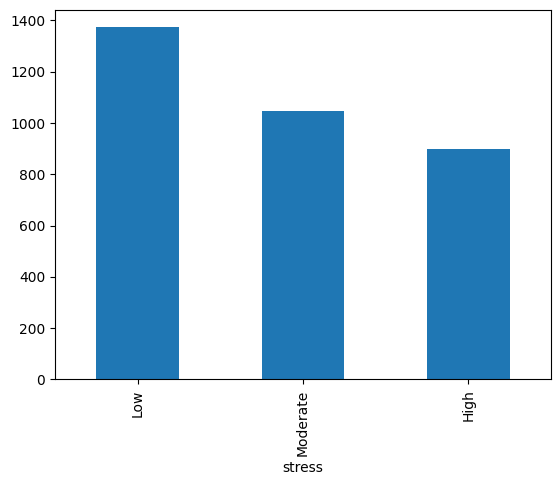

In [ ]:
merged['stress'].value_counts().plot(kind='bar')

Every phase is well-balanced and well-populated. Given the mild imbalance and multiclass setting, macro-F1 is the primary metric, with stratified grouped splits and optional class weighting.

### Feature Engineering (includes feature importance + stratification)

**Stratification**

The research question is which physiological indicators best predict stress across menstrual cycle phases. The complication is that cycle phase itself changes those same physiological signals — independently of stress. Progesterone, which rises in the luteal phase, raises skin temperature, suppresses heart rate variability, and shifts other autonomic measures. So when you see a high temperature or low HRV reading, there are two possible explanations tangled together: the person is stressed, or they're simply in a phase where that signal is naturally elevated. So, phase becomes a confound.

For example, the model might notice that high temperature days tend to be labeled a certain way — but if temperature is high mostly because of the luteal progesterone shift rather than stress, the model has learned a phase pattern and is presenting it as a stress prediction.

To handle this, I will use **stratification**. I will split the data by phase and analyze each phase separately. So when I look at the variation in temperature among luteal days, that variation can no longer be explained by "luteal versus follicular," because they're all luteal. What's left is variation that's stress-related.

So stratificaiton doesn't just contorl this confound but answers my question to find which indicators are most predictive across the different phases.


Therefore, phase will not be considered a feature. That's because within the luteal subset, every single row is luteal. So a phase column there would be the same value for every row.

And, **as will be described in the splitting section**, within each phase's subset, I will still apply grouped cross-validation on participant ID, so the same person never appears in both training and validation of a given phase's model, handling the separate leakage issue from repeated measures.

**Defining the columns**

In [ ]:
key = ['id', 'study_interval', 'day_in_study']
target_col = 'stress'          # Low / Moderate / High
group_col = 'id'               # for GroupKFold
slice_col = 'phase'           # what I will slice by

feature_cols = [c for c in merged.columns
                if c not in key + [target_col, slice_col]]
print("Features:", feature_cols)
print("Count:", len(feature_cols))

Features: ['mean_temp', 'max_temp', 'min_temp', 'std_temp', 'mean_rmssd', 'max_rmssd', 'min_rmssd', 'std_rmssd', 'mean_high_frequency', 'max_high_frequency', 'min_high_frequency', 'std_high_frequency', 'mean_vo2', 'max_vo2', 'min_vo2', 'std_vo2', 'mean_bpm', 'max_bpm', 'min_bpm', 'std_bpm']
Count: 20


**Target Encoding**

Low: 0

Moderate: 1

High: 2

In [ ]:
stress_map = {'Low': 0, 'Moderate': 1, 'High': 2}
merged['stress_encoded'] = merged['stress'].map(stress_map)

**is_weekend** was a useful behavioural feature because stress patterns differ weekday vs weekend. However there is 13% missing values and can't impute. Dropping isn't a good option because I would be dropping lots of rows and losing data. I explored the idea of calculating the days to decide whether it was a weekend or not but I don't know whether the participants started on Monday and if the days were actuall consecutive. So, I will not be incuding is_weekend.

**Scaling**

Since my features are on different scales, distance between values can dominate. So I will use z-score standardization

### Data Splitting and Validation

**Data Splitting**

I will be doing a **stratified** data split. As explained, I will hold phase constant by analyzing each phase separately. For example, within the luteal subset every row is luteal, so the phase-driven baseline is constant, and remaining variation is closer to stress-related.

So, I'm doing a model for each phase.

**Validation**

Within each phase, models are evaluated using 5-fold cross-validation with StratifiedGroupKFold (split data into 5 parts, train on 4, test on 1, rotate 5 times, average the results).
- This groups by participant ID so the same person never appears in both training and test folds — important because there are repeated daily measurements per participant, and mixing them would let the model recognise individuals rather than learn stress patterns.
  - StratifiedGroupKFold does this by assigning whole participants to folds, not individual rows.
- It also stratifies by stress class, preserving the Low/Moderate/High balance in each fold.
  - StratifiedGroupKFold does this where while assigning participants to folds, it also tries to make each fold have roughly the same proportion of Low/Moderate/High as the overall data.
  - Every phase was verified as well-populated, so per-phase modelling is viable.

**It's 5-fold so that 4/5 (80%) is for training and 1/5 (20%) is for testing**

Feature importance will then compared across phases to see which signals best predict stress in each.
